In [2]:
import torch
from torch import nn
import torch_geometric
from torch_geometric.nn import SAGEConv, GraphConv, GraphSAGE
import torch
import networkx as nx 
from torch.utils.data import Dataset, DataLoader
import pickle
import pdb 
import numpy as np
from torch_geometric.data import Data
import networkx as nx
import numpy as np
import pandas as pd 
import pickle
import pdb
from torch_geometric.loader import DataLoader
import torch.optim as optim
import torch.nn.functional as F
from torch_geometric.utils import to_dense_adj, subgraph, k_hop_subgraph
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.join(os.path.dirname(sys.path[0]),'tools'))
sys.path.append(os.path.join(os.path.dirname(sys.path[0]),'sim'))
from sklearn.neighbors import kneighbors_graph
from torch.optim.lr_scheduler import ReduceLROnPlateau
from ClassGraphDat import GraphDataset
from params import ENVIRONMENT_BOUNDARY_X, COMMIT_THRESHOLD
from sklearn.neighbors import kneighbors_graph
from scipy.spatial import ConvexHull
MAX_DIST=ENVIRONMENT_BOUNDARY_X[-1]
STATES_LIST = ['RECRUIT', 'ASSESS', 'TRAVEL_HOME_TO_RECRUIT', 'TRAVEL_SITE', 'OBSERVE', 'EXPLORE', 'TRAVEL_HOME_TO_OBSERVE']
STATES = {'RECRUIT':0.0/6.0, 'ASSESS':1.0/6.0, 'TRAVEL_HOME_TO_RECRUIT':2.0/6.0, 'TRAVEL_SITE':3.0/6.0, 
          'OBSERVE':4.0/6.0, 'EXPLORE':5.0/6.0, 'TRAVEL_HOME_TO_OBSERVE':6.0/6.0}
torch.manual_seed(42)
CLIST = ["Slow/Success", "Fast/Success", "Slow/Failure", "Fast/Failure"]
TIME_LIMIT_FOR_SLOW = 200
SUCCESS_LIMIT = 0.5
LEN_STATES = 7

In [3]:
def get_class(success, time):
    if success > SUCCESS_LIMIT and time > TIME_LIMIT_FOR_SLOW:
        cl = [0, 0, 0, 1] #CLIST[0]
    elif success > SUCCESS_LIMIT and time <= TIME_LIMIT_FOR_SLOW:
        cl = [0, 0, 1, 0] #CLIST[1]
    elif success <= SUCCESS_LIMIT and time > TIME_LIMIT_FOR_SLOW:
        cl = [0, 1, 0, 0] #CLIST[2]
    elif success <= SUCCESS_LIMIT and time <= TIME_LIMIT_FOR_SLOW:
        cl = [1, 0, 0, 0] #CLIST[3]
    return cl

CLIST =  ["Fast/Failure", "Slow/Failure", "Fast/Success", "Slow/Success"]


In [5]:
# def oneHotToState( st):
#     newx = []
#     i=0
#     while i < 10:
#         state = np.round(STATES[STATES_LIST[st[10*i:10*i+7].index(1)]], 3)
#         newx.append(state)
#         for j in range(10*i+7, 10*i+10):
#             newx.append(st[j])
#         i += 1
#     return newx

folder_graph = './finished_trials/'
files = os.listdir(folder_graph)
files = [file for file in files if file.endswith('.pickle')]
new = './finished_0p5/'
# arr = dict()
# arr1 = []
# arrpos = []
# arrqual = []
# arrcol = []
# arrclass = []
# arr_global_info = []
# arr_num_agents = []

# keep_failures = 10
# counter = 0
# metadata = pd.read_csv('./graphsage_results/CDC/multiple_agent_env_results/metadata.csv')
for file in files[:-1]:
    fil =  open(folder_graph+file, 'rb')
    G = pickle.load(fil)
    fil.close()
    # if G.nodes[0]['success'] > 0.5
    # pdb.set_trace()

    # nA = file.split(')')[-1][:2]
    # if nA[-1] == '_':
    #     num_agents = int(file.split(')')[-1][0])
    # else:
    #     num_agents = int(file.split(')')[-1][:2])

    for node in G.nodes(data=True):
        G.nodes[node[0]]['classes'] = get_class(node[1]['success'], node[1]['time'])

    # print('Processed: ', fil)
    fil =  open(new+file, 'wb')
    pickle.dump(G, fil)   
    fil.close() 
        # if G.nodes[node[0]]['success'] > 0.5
    #     # pdb.set_trace()
    #     G.nodes[node[0]]['x'] = tuple(oneHotToState(node[1]['x']))
        
        # # pdb.set_trace()
        # if tuple(oneHotToState(node[1]['x'])) in arr:
        #     continue
        # else:

        #     arrclass.append(list(node[1]['classes']))
        #     arr1.append(oneHotToState(node[1]['x']))#+list(node[1]['global_info']))
        #     arr[tuple(oneHotToState(node[1]['x']))] = node[1]['colors']  




In [ ]:
# class GraphEncoderWithResidual(nn.Module):
#     def __init__(self, in_channels, hidden_channels, out_channels):
#         super(GraphEncoderWithResidual, self).__init__()
#         self.conv1 = SAGEConv(in_channels, hidden_channels*2)
#         self.bn1 = nn.BatchNorm1d(hidden_channels*2)
#         self.conv2 = SAGEConv(hidden_channels*2, hidden_channels)
#         self.bn2 = nn.BatchNorm1d(hidden_channels)
#         self.lin = nn.Linear(hidden_channels, out_channels)
#         self.shortcut = nn.Linear(in_channels, out_channels)

#     def forward(self, x, edge_index):
#         identity = self.shortcut(x)
#         x = F.relu(self.bn1(self.conv1(x, edge_index)))
#         x = F.relu(self.bn2(self.conv2(x, edge_index)))
#         x = self.lin(x)
#         x += identity
#         return x


# class GraphEncoderWithResidual(nn.Module):
#     def __init__(self, in_channels, hidden_channels, out_channels):
#         super(GraphEncoderWithResidual, self).__init__()
#         self.conv1 = SAGEConv(in_channels, hidden_channels*2)
#         self.conv2 = SAGEConv(hidden_channels*2, hidden_channels)
#         # self.conv3 = SAGEConv(hidden_channels, out_channels)
#         self.lin = nn.Linear(hidden_channels, out_channels)
#         # Linear transformation to match dimensions for residual connection
#         self.shortcut = nn.Linear(in_channels, out_channels)
#         # self.sm = nn.Softmax(dim=1)

#     def forward(self, x, edge_index):
#         identity = x
#         x = F.relu(self.conv1(x, edge_index))
#         x = F.relu(self.conv2(x, edge_index))
#         # x = self.conv3(x, edge_index)
#         x = self.lin(x)
#         # Applying shortcut and adding it to the output of conv3
#         identity = self.shortcut(identity)
#         x += identity  # Element-wise addition
#         # print('before: ', x[0])
#         # print(np.shape(x))
#         # x = self.sm(x)
#         # print('after: ', x[0])
#         return x

In [ ]:
# class FocalLoss(nn.Module):
#     def __init__(self, alpha=0.25, gamma=2.0):
#         super(FocalLoss, self).__init__()
#         self.alpha = alpha
#         self.gamma = gamma

#     def forward(self, inputs, targets):
#         BCE_loss = F.cross_entropy(inputs, targets, reduction='none')
#         pt = torch.exp(-BCE_loss)  # Prevents nans when the loss is zero
#         F_loss = self.alpha * (1-pt)**self.gamma * BCE_loss
#         return torch.mean(F_loss)

# focal_loss = FocalLoss(alpha=0.25, gamma=2.0)

# # Assuming a loss function appropriate for node feature reconstruction, e.g., MSE for continuous features
# def loss_function(reconstructed_x, original_x):

#     # print(/)
#     # bce_loss_fn = torch.nn.BCEWithLogitsLoss()
#     # loss = bce_loss_fn(logits, one_hot_targets)
#     # weights = torch.tensor([ 662843/17722.0,  662843/49808.0, 662843/209018.0, 662843/386295.0], dtype=torch.float)
#     # weights = weights/torch.sum(weights)
#     return F.cross_entropy(reconstructed_x, original_x)#, weight=weights, label_smoothing=0.2)

# # bce_loss_fn = torch.nn.BCEWithLogitsLoss()
# # loss = bce_loss_fn(logits, one_hot_targets)
# # print(loss) 

# def cosine_loss(adj, emb):
#     norms = torch.norm(emb, p=2, dim=1, keepdim=True)
#     normalized_embeddings = emb / norms.clamp(min=1e-4)
#     cosine_similarity_matrix = torch.mm(normalized_embeddings, normalized_embeddings.t())
#     target_adjacency = torch.zeros_like(cosine_similarity_matrix)
#     target_adjacency[adj[0], adj[1]] = 1
#     # Directly using logits; no need to apply sigmoid.
#     return F.binary_cross_entropy_with_logits(cosine_similarity_matrix, target_adjacency)

In [ ]:
# def train(model, data_loader, optimizer, device):
#     model.train()
#     total_loss = 0
#     embeddings = []
#     origs = []
#     # lossfunc = nn.CrossEntropyLoss()
#     # print(data_loader)
#     for data in data_loader:
#         optimizer.zero_grad()
#         # print(np.shape(data[0][0]), np.shape(data[1][0]), np.shape(data[2][0]))
#         embed = model(data[0][0].to(device), data[1][0].to(device))
        
#         # origs.append(data[0][0].detach())
#         # print(np.shape(embed), np.shape(data[2][0]))
#         # print()
#         # print(data[2][0][0], embed[0].detach())
#         # loss = lossfunc(embed, data[2][0].to(device))
#         # print(np.shape(embed), np.shape(data[2][0]), np.shape(data[0][0]), np.shape(data[1][0]))
#         # print()
#         # print(data[2][0], np.shape(embed), np.shape(data[2][0]))
#         loss = loss_function(embed, data[2][0].to(device)) #cosine_loss(data[1][0].to(device), embed)
#         # loss = focal_loss(embed, data[2][0].to(device)) #cosine_loss(data[1][0].to(device), embed)
#         loss.backward()
#         optimizer.step()
#         total_loss += loss.item()
#         # embeddings.append(embed.detach())
#         # print(total_loss)
#     return total_loss / len(data_loader), embeddings, origs

In [ ]:
# folder_graph = './classGraphs/'
# device = "cpu"
# # fname = 'small_graphs.pth'
# files = os.listdir(folder_graph)
# files = [file for file in files if file.endswith('.pickle')]
# hC = 20
# inC = 40

# dataset = GraphDataset(folder_graph, files)

# dataloader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=8)
# actuals = []
# final_loss = []
# embeddings = []
# outchannels = 4
# model = GraphEncoderWithResidual(in_channels=inC, hidden_channels=hC, out_channels=outchannels).to(device)
# optimizer = optim.Adam(model.parameters(), lr=0.01)
# # scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.1, patience=3, verbose=True)
# losses = []
# embeds = []
# acts = []
# for epoch in range(1, 5):  # Number of epochs
#     loss, embed, orig = train(model, dataloader, optimizer, device)
#     # embeds.append(embed)
#     # acts.append(orig)
#     print(f'Epoch {epoch}, Loss: {loss:.4f}')
#     # losses.append(loss)
#     # scheduler.step(loss)
# # epoch_loss = loss / len(dataloader)
# # embeddings.append(embeds)
# # final_loss.append(losses)
# # actuals.append(acts)

# # Assuming encoder and decoder are your model's components
# encoder_state_dict = model.state_dict()
# # decoder_state_dict = model.decoder.state_dict()
# # Save the state dictionaries
# torch.save(encoder_state_dict, './LinClass_encoder_state_dict'+str(outchannels)+'.pth')
# # torch.save(decoder_state_dict, './CDC/decoder_state_dict'+str(outchannels)+'.pth')
#         # print(np.shape(embed), np.shape(data[2][0]), np.shape(data[0][0]), np.shape(data[1][0]))


Epoch 1, Loss: 0.8528
Epoch 2, Loss: 0.8472
Epoch 3, Loss: 0.8477
Epoch 4, Loss: 0.8481


In [ ]:
# optimizer = optim.Adam(model.parameters(), lr=0.001)

# for epoch in range(1, 5):  # Number of epochs
#     loss, embed, orig = train(model, dataloader, optimizer, device)
#     # embeds.append(embed)
#     # acts.append(orig)
#     print(f'Epoch {epoch}, Loss: {loss:.4f}')
#     # losses.append(loss)

# encoder_state_dict = model.state_dict()
# torch.save(encoder_state_dict, './LinClass_encoder_state_dict'+str(outchannels)+'.pth')


Epoch 1, Loss: 0.7910
Epoch 2, Loss: 0.7907
Epoch 3, Loss: 0.7906
Epoch 4, Loss: 0.7908


In [ ]:
# optimizer = optim.Adam(model.parameters(), lr=0.0001)

# for epoch in range(1, 5):  # Number of epochs
#     loss, embed, orig = train(model, dataloader, optimizer, device)
#     # embeds.append(embed)
#     # acts.append(orig)
#     print(f'Epoch {epoch}, Loss: {loss:.4f}')
#     # losses.append(loss)

# encoder_state_dict = model.state_dict()
# torch.save(encoder_state_dict, './LinClass_encoder_state_dict'+str(outchannels)+'.pth')

Epoch 1, Loss: 0.7852
Epoch 2, Loss: 0.7851
Epoch 3, Loss: 0.7852
Epoch 4, Loss: 0.7851


In [ ]:
# sf = nn.Softmax(dim=1)
# x = torch.tensor([[-0.5207, -0.6732,  0.1790, -0.5166], [-0.3699, -0.7055, -0.0155, -0.2880]])
# print(np.shape(x))
# print(sf(x))

In [ ]:


# torch.manual_seed(42)

# class GraphEncoderWithResidual(nn.Module):
#     def __init__(self, in_channels, hidden_channels, out_channels):
#         super(GraphEncoderWithResidual, self).__init__()
#         self.conv1 = SAGEConv(in_channels, hidden_channels*2)
#         self.conv2 = SAGEConv(hidden_channels*2, hidden_channels)
#         # self.conv3 = SAGEConv(hidden_channels, out_channels)
#         self.lin = nn.Linear(hidden_channels, out_channels)
#         # Linear transformation to match dimensions for residual connection
#         self.shortcut = nn.Linear(in_channels, out_channels)
#         # self.sm = nn.Softmax(dim=1)

#     def forward(self, x, edge_index):
#         identity = x
#         x = F.relu(self.conv1(x, edge_index))
#         x = F.relu(self.conv2(x, edge_index))
#         # x = self.conv3(x, edge_index)
#         x = self.lin(x)
#         # Applying shortcut and adding it to the output of conv3
#         identity = self.shortcut(identity)
#         x += identity  # Element-wise addition
#         # print('before: ', x[0])
#         # print(np.shape(x))
#         # x = self.sm(x)
#         # print('after: ', x[0])
#         return x
    
    


# def node_to_color_black(node):
#     if node[9] == 0.0:
#         return True
#     else:
#         return False

# def node_to_color_green(node, quals):
#     # pdb.set_trace()
#     nA = np.sum([1 for _ in node[0::10]])
#     dancers = [(1, q) for a, q in zip(node[0::10], node[9::10]) if a == 1]
#     qs = [0]*4
#     # pdb.set_trace()
#     for d in dancers:
#         ii = quals.index(d[1])
#         qs[ii] += 1

#     if np.max(qs) > COMMIT_THRESHOLD*nA:
#         id = np.argmax(qs)
#         if quals[id] == np.max(quals):
#             return True
#         else:
#             return False
#     else:
#         return False
    
# def node_to_color_red(node, quals):
#     # pdb.set_trace()
#     nA = np.sum([1 for _ in node[0::10]])
#     dancers = [(1, q) for a, q in zip(node[0::10], node[9::10]) if a == 1]
#     qs = [0]*4
#     # pdb.set_trace()
#     for d in dancers:
#         ii = quals.index(d[1])
#         qs[ii] += 1

#     if np.max(qs) > COMMIT_THRESHOLD*nA:
#         id = np.argmax(qs)
#         if quals[id] != np.max(quals):
#             return True
#         else:
#             return False
#     else:
#         return False
    
# def get_color(node, quals):
#     red = node_to_color_red(node, quals)
#     green = node_to_color_green(node, quals)
#     black = node_to_color_black(node)
#     if red is True:
#         return 'r'
#     elif green is True:
#         return 'g'
#     elif black is True:
#         return 'k'
#     else:
#         return 'b'

# # def get_full_qual(q):
# #     while len(q) < 4:
# #         q.append(0.0)
# #     return q

    

# def get_complete_poses(a):
#     arr = [[MAX_DIST]*2]*4
#     for i in range(0,len(a)):
#         # pdb.set_trace()
#         arr[i] = list(a[i])
#     # pdb.set_trace()
#     return arr

# def get_complete_quals(a):
#     arr = [[0]*2]*4
#     for i in range(0,len(a)):
#         # pdb.set_trace()
#         arr[i] = a[i]
#     # pdb.set_trace()
#     return arr

# def get_complete_global(a):
#     arr = [0]*4
#     for i in range(0,len(a)):
#         # pdb.set_trace()
#         arr[i] = a[i]
#     # pdb.set_trace()
#     return arr



In [ ]:
# print(np.shape(arrclass), np.shape(emb))

# y_true_indices = np.argmax(arrclass, axis=1)
# y_pred_indices = np.argmax(emb, axis=1)


(797377, 4) (797377, 4)


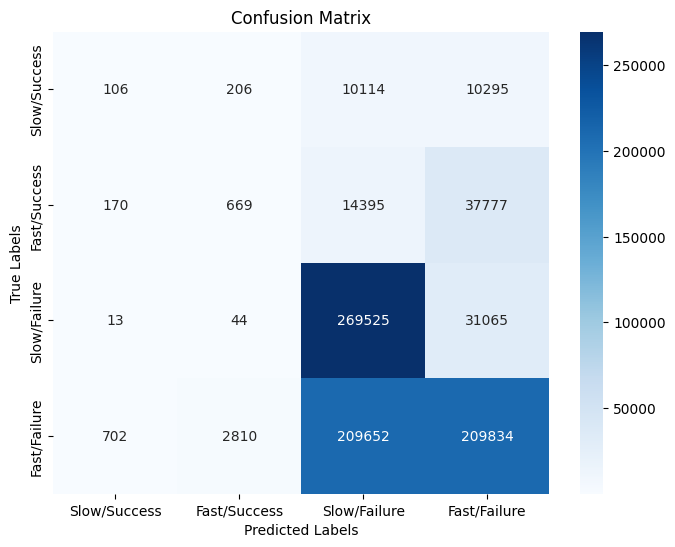

In [ ]:
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# import seaborn as sns
# cm = confusion_matrix(y_true_indices, y_pred_indices)
# # ConfusionMatrixDisplay(cm).plot()
# CLIST = ["Slow/Success", "Fast/Success", "Slow/Failure", "Fast/Failure"]
# # Plotting the confusion matrix
# plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=CLIST, yticklabels=CLIST)
# plt.xlabel('Predicted Labels')
# plt.ylabel('True Labels')
# plt.title('Confusion Matrix')
# plt.show()
# 

In [ ]:
# total = np.sum(cm, axis=1)
# print(total)
# print(cm)

[ 20721  53011 300647 422998]
[[   106    206  10114  10295]
 [   170    669  14395  37777]
 [    13     44 269525  31065]
 [   702   2810 209652 209834]]


In [ ]:
# STATES_LIST = ['RECRUIT', 'ASSESS', 'TRAVEL_HOME_TO_RECRUIT', 'TRAVEL_SITE', 'OBSERVE', 'EXPLORE', 'TRAVEL_HOME_TO_OBSERVE']
# STATES = {'RECRUIT':0.0/6.0, 'ASSESS':1.0/6.0, 'TRAVEL_HOME_TO_RECRUIT':2.0/6.0, 'TRAVEL_SITE':3.0/6.0, 
#           'OBSERVE':4.0/6.0, 'EXPLORE':5.0/6.0, 'TRAVEL_HOME_TO_OBSERVE':6.0/6.0}

# folder_graph = './classGraphs/'
# files = os.listdir(folder_graph)
# files = [file for file in files if file.endswith('.pickle')]
# file = files[0]
# # for file in files[:-1]:
# fil =  open(folder_graph+file, 'rb')
# G = pickle.load(fil)
# fil.close()

# newx = []
# i=0
# while i < 10:
#     st = G.nodes[100]['x']
#     state = np.round(STATES[STATES_LIST[st[10*i:10*i+7].index(1)]], 3)
#     # print(STATES[state], G.nodes[0]['x'][10*i:10*i+7])
#     newx.append(state)
#     for j in range(10*i+7, 10*i+10):
#         newx.append(st[j])
#     i += 1
# print(st)
# print(newx)
